# Decision Tree Assignment

** Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.

- A Decision Tree is a supervised machine learning algorithm used for:

Classification (e.g., Spam vs Not Spam)

Regression (e.g., Predicting house prices)



A Decision Tree's structure is hierarchical, resembling an upside-down tree:

*   **Root Node:** This is the starting point of the decision tree. It represents the entire dataset and the initial decision or question that splits the data into different branches.
*   **Internal Nodes (Decision Nodes):** These nodes represent a feature or attribute that is used to make a decision. Based on the outcome of the decision, the data is split into further sub-nodes.
*   **Leaf Nodes (Terminal Nodes):** These are the final nodes in the tree, representing the predicted outcome or class label. They do not split further.

### Real-life Example: Deciding Whether to Play Tennis

Let's imagine you want to decide if you should play tennis based on the weather conditions. Here's how a Decision Tree would look:

*   **Root Node:** "Outlook" (Is it Sunny, Overcast, or Rainy?)
    *   If **Outlook** is **Overcast**: You decide to play tennis. (Leaf Node)
    *   If **Outlook** is **Sunny**: This leads to an internal node: "Humidity"
        *   If **Humidity** is **High**: You decide not to play. (Leaf Node)
        *   If **Humidity** is **Normal**: You decide to play. (Leaf Node)
    *   If **Outlook** is **Rainy**: This leads to an internal node: "Wind"
        *   If **Wind** is **Strong**: You decide not to play. (Leaf Node)
        *   If **Wind** is **Weak**: You decide to play. (Leaf Node)

In this example:
*   The **Root Node** is "Outlook".
*   The **Internal Nodes** are "Humidity" (under Sunny) and "Wind" (under Rainy).
*   The **Leaf Nodes** are the final decisions: "Play" or "Don't Play" tennis.

**Q2. Differentiate between Gini Impurity and Entropy.

Which one is used by default in Scikit-learn and why?**

Both **Gini Impurity** and **Entropy** are metrics used in Decision Trees to measure the impurity or disorder of a set of samples. The goal of a Decision Tree algorithm is to choose the splits that minimize this impurity.

### Gini Impurity

*   **Definition:** Gini impurity measures how often a randomly chosen element from the set would be incorrectly labeled if it were randomly labeled according to the distribution of labels in the subset. A Gini impurity of 0 means all elements belong to a single class (perfect purity), while a Gini impurity of 1 implies a perfectly even distribution of classes (maximum impurity).
*   **Formula:** For a node, if `p_i` is the probability of an item being classified into class `i`, then Gini Impurity is calculated as:
    `Gini = 1 - Σ (p_i)^2` (sum over all classes `i`)
*   **Nature:** It tends to isolate the most frequent class in its own branch. It is computationally less expensive to calculate compared to entropy because it doesn't involve logarithms.

### Entropy

*   **Definition:** Entropy, borrowed from information theory, measures the average level of 'information' or 'uncertainty' or 'disorder' in a set of samples. A higher entropy indicates greater disorder, and an entropy of 0 indicates perfect purity (all samples belong to the same class).
*   **Formula:** For a node, if `p_i` is the probability of an item being classified into class `i`, then Entropy is calculated as:
    `Entropy = - Σ p_i * log2(p_i)` (sum over all classes `i`)
*   **Nature:** It aims to produce a more balanced tree, potentially considering all possible classifications more equally. It is computationally more intensive due to the logarithm function.

### Key Differences

| Feature        | Gini Impurity                                          | Entropy                                                           |
| :------------- | :----------------------------------------------------- | :---------------------------------------------------------------- |
| **Calculation**  | Uses sum of squares                                    | Uses logarithms                                                   |
| **Computational Cost** | Faster                                               | Slower                                                            |
| **Focus**        | Tends to isolate the most frequent class               | Tends to produce a more balanced tree                             |
| **Range**        | 0 to 0.5 (for binary classification); generally 0 to 1 | 0 to 1 (for binary classification); generally 0 to log2(num_classes) |

### Default in Scikit-learn

**Scikit-learn's `DecisionTreeClassifier` uses Gini Impurity (`criterion='gini'`) as its default criterion.**

**Why?**

1.  **Computational Efficiency:** Gini impurity is computationally less expensive to calculate because it avoids the use of logarithmic functions, which are required for entropy. This can lead to faster training times, especially for large datasets.
2.  **Similar Performance:** In most practical scenarios, the choice between Gini impurity and entropy often makes little difference to the overall performance of the decision tree. Both criteria generally lead to very similar trees and classification accuracies.
3.  **No Significant Advantage:** While entropy might sometimes produce slightly more balanced trees, Gini impurity is often sufficient and effective for finding good splits, without the added computational overhead.

** Q3. What is Overfitting in Decision Trees?
How can we detect it using training and testing accuracy?**

### What is Overfitting in Decision Trees?

**Overfitting** occurs when a machine learning model learns the training data too well, including its noise and random fluctuations, to the extent that it performs poorly on unseen or new data. In the context of Decision Trees, an overfitted model is typically a very complex tree with many branches and deep levels, often reaching a point where leaf nodes contain only a few or even just one training example. This means the tree has essentially memorized the training data rather than learning generalizable patterns.

Key characteristics of an overfitted Decision Tree:
*   It has high variance (sensitive to small fluctuations in the training data).
*   It captures noise in the training data.
*   It generalizes poorly to new data.

### How to Detect Overfitting Using Training and Testing Accuracy

Detecting overfitting is crucial for building a robust model. The most common and effective way to detect overfitting is by comparing the model's performance on the **training dataset** versus its performance on an independent **testing (or validation) dataset**.

Here's how:

1.  **Split the Data:** Before training, split your dataset into two (or three) parts:
    *   **Training Set:** Used to train the Decision Tree model.
    *   **Testing Set (or Validation Set):** Used to evaluate the model's performance on unseen data. This set should not be used during training.

2.  **Train the Model:** Train your Decision Tree model using only the training data.

3.  **Evaluate Performance:** Calculate the accuracy (or another appropriate metric like F1-score, precision, recall) of the model on both the training set and the testing set.

    *   **Training Accuracy:** How well the model performs on the data it was trained on.
    *   **Testing Accuracy:** How well the model performs on new, unseen data.

4.  **Analyze the Results:**
    *   **High Training Accuracy & Low Testing Accuracy:** This is the classic sign of **overfitting**. The model has learned the training data exceptionally well (high training accuracy), but it struggles to generalize to new data (low testing accuracy). The large gap between training and testing accuracy indicates that the model is too complex for the problem and has memorized the training noise.
    *   **Low Training Accuracy & Low Testing Accuracy:** This indicates **underfitting**. The model is too simple and hasn't even learned the training data well, let alone new data. This might happen with a very shallow Decision Tree.
    *   **High Training Accuracy & High Testing Accuracy (with a small, acceptable gap):** This is the ideal scenario, indicating a **well-generalized model**. The model has learned patterns effectively from the training data and can apply them successfully to new data.

**In summary:** A significant discrepancy where the training accuracy is much higher than the testing accuracy is the primary indicator of overfitting in a Decision Tree.

Q4. Explain Pruning in Decision Trees.
What is the difference between Pre-pruning and Post-pruning?

### What is Pruning in Decision Trees?

**Pruning** is a technique used in Decision Trees to reduce the size of the tree by removing sections of the tree that provide little power to classify instances. It's a crucial method for combating **overfitting**. A fully grown decision tree can be overly complex and fit the training data too closely, including its noise, which leads to poor generalization on unseen data. Pruning helps simplify the tree, making it more generalized and interpretable, while ideally improving its predictive accuracy on new data.

There are two main types of pruning:

1.  **Pre-pruning (or Early Stopping)**
2.  **Post-pruning (or Backward Pruning)**

### Difference between Pre-pruning and Post-pruning

| Feature            | Pre-pruning (Early Stopping)                                                                                                    | Post-pruning (Backward Pruning)                                                                                                              |
| :----------------- | :------------------------------------------------------------------------------------------------------------------------------ | :------------------------------------------------------------------------------------------------------------------------------------------- |
| **Timing**         | Stops the tree construction early, before it is fully grown. It decides whether to split a node or make it a leaf node during the tree building process. | Builds the full decision tree first, and then removes branches from it. It prunes the tree after it has been fully grown.                          |
| **Mechanism**      | Uses criteria to decide whether to stop splitting a node. If splitting a node does not significantly improve the model's performance (e.g., reduces impurity below a threshold, or doesn't meet a minimum number of samples per leaf), the split is avoided. | Examines the fully grown tree and removes (or collapses) subtrees that provide little additional predictive power, often using a validation set to guide the process. |


| **Common Criteria** | *   `max_depth`: Maximum depth of the tree.
|                    | *   `min_samples_split`: Minimum number of samples required to split an internal node.
|                    | *   `min_samples_leaf`: Minimum number of samples required to be at a leaf node.
|                    | *   `max_leaf_nodes`: Maximum number of leaf nodes.
|                    | *   `cost_complexity_pruning` (`ccp_alpha`): A threshold for pruning based on cost complexity (used in Scikit-learn). | *   Reduced Error Pruning: Iteratively remove nodes that, when removed, do not increase the error on a validation set.
|                    | *   Cost-Complexity Pruning (Weakest Link Pruning): Prune subtrees based on a trade-off between tree size and error rate. |
| **Advantages**     | *   Generally faster to build the tree.
|                    | *   Avoids generating unnecessary branches.
|                    | *   Can lead to simpler trees from the start.                                                                                   | *   Can find optimal subtrees that might be missed by pre-pruning (because pre-pruning might stop a promising split too early).
|                    | *   Often leads to more accurate trees than pre-pruning (if done correctly).                                                |
| **Disadvantages**  | *   May stop growing a branch prematurely, leading to a phenomenon called the "horizon effect," where it might miss some good splits further down the tree. | *   Computationally more expensive as it first builds a complete (potentially overfitted) tree and then prunes it.
|                    | *   Requires a separate validation set for some methods to evaluate the impact of pruning.                                |
| **Usage in Scikit-learn** | Parameters like `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes` in `DecisionTreeClassifier` and `DecisionTreeRegressor`. | `ccp_alpha` parameter in `DecisionTreeClassifier` and `DecisionTreeRegressor` (implements cost-complexity pruning). |

In essence, pre-pruning is a "stop-early" approach, while post-pruning is a "build-then-cut" approach.

Q5. What is Feature Importance?
How can it help businesses in decision-making?

### What is Feature Importance?

**Feature Importance** refers to techniques that assign a score to input features based on how useful or important they are in predicting a target variable (the outcome you're trying to model). In the context of Decision Trees (and other tree-based models like Random Forests or Gradient Boosting), feature importance is often calculated based on how much each feature contributes to reducing impurity (like Gini impurity or entropy) across all the splits it's involved in throughout the tree. The more a feature is used to make key splits early in the tree, and the more it reduces impurity, the higher its importance score.

Essentially, it quantifies the degree to which a particular feature affects the model's predictions.

### How Can Feature Importance Help Businesses in Decision-Making?

Feature importance is a powerful tool for businesses because it transforms complex model outputs into actionable insights. Here are several ways it can help:

1.  **Prioritization of Resources:**
    *   **Example:** A marketing team wants to improve customer conversion rates. Feature importance analysis on a customer conversion model reveals that "customer's past purchase frequency" and "engagement with email campaigns" are the most important features. This tells the marketing team to invest more in strategies that boost these two areas, rather than less impactful factors.

2.  **Product Development and Improvement:**
    *   **Example:** For a product recommendation system, feature importance shows that "product category" and "user's browsing history" are far more influential than "user's demographic information." This helps the product team focus on refining product categorization and personalizing browsing experiences.

3.  **Risk Management and Fraud Detection:**
    *   **Example:** A bank uses a model to detect fraudulent transactions. Feature importance highlights that "transaction amount," "location of transaction compared to user's usual location," and "frequency of transactions within a short period" are the top indicators of fraud. The bank can then develop stricter rules or real-time alerts around these specific factors.

4.  **Customer Churn Prevention:**
    *   **Example:** A telecom company analyzes customer churn. Feature importance reveals that "average monthly data usage," "customer service interaction history," and "contract type" are the most significant predictors. The company can proactively target customers with low data usage, poor service experiences, or expiring contracts with retention offers.

5.  **Optimizing Business Processes:**
    *   **Example:** In manufacturing, a model predicts product defects. Feature importance identifies "temperature during assembly" and "supplier of raw material X" as critical factors. This allows the company to implement tighter controls on temperature and evaluate alternative suppliers for material X.

6.  **Regulatory Compliance and Explainability:**
    *   **Example:** In regulated industries like finance or healthcare, models often need to be explainable. Feature importance provides a clear, quantitative basis for understanding *why* a model made a certain decision (e.g., why a loan was denied), helping to satisfy regulatory requirements and build trust.

7.  **Feature Engineering and Model Simplification:**
    *   **Example:** If certain features consistently show very low importance, a business might decide to exclude them from future models. This can simplify the data collection process, reduce storage costs, speed up model training, and potentially improve model performance by removing noise.

By understanding which factors drive model predictions, businesses can make more informed, data-driven decisions, allocate resources more effectively, identify key leverage points for improvement, and gain deeper insights into their operations and customer behavior.

** Q6. Data Understanding**

Load the dataset

Display first 5 rows

Check:

Shape

Data types

Column names

**Interpret**:

What types of variables are present?

In [1]:
# Import the Essential Libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the dataset
df=pd.read_csv('/content/bank.csv')

In [3]:
# Display first 5 rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
# Shape
df.shape

(11162, 17)

In [5]:
# Data types
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [6]:
# Column names
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

Based on the `df.dtypes` output, the dataset contains the following types of variables:

*   **Numerical Variables (`int64`):** These are quantitative variables that represent measurable quantities. Examples from your dataset include:
    *   `age`: The age of the individuals.
    *   `balance`: The average yearly balance, in euros.
    *   `day`: The day of the month.
    *   `duration`: Last contact duration in seconds. (Note: This attribute highly affects the output target (e.g., if duration=0 then deposit='no'). The duration is not known before a call is performed. Also, after the end of the call, `duration` is known. Thus, if the duration is included, it would be a perfect predictor for the target. This column should usually be dropped for a predictive model.)
    *   `campaign`: Number of contacts performed during this campaign and for this client.
    *   `pdays`: Number of days that passed by after the client was last contacted from a previous campaign. -1 means client was not previously contacted.
    *   `previous`: Number of contacts performed before this campaign and for this client.

*   **Categorical Variables (`object`):** These are qualitative variables that represent categories or labels. Examples from your dataset include:
    *   `job`: Type of job.
    *   `marital`: Marital status.
    *   `education`: Education level.
    *   `default`: Has credit in default? (yes/no)
    *   `housing`: Has housing loan? (yes/no)
    *   `loan`: Has personal loan? (yes/no)
    *   `contact`: Contact communication type.
    *   `month`: Last contact month of year.
    *   `poutcome`: Outcome of the previous marketing campaign.
    *   `deposit`: Has the client subscribed to a term deposit? (yes/no - This is likely your target variable).

** Q7. Data Cleaning**

Check for missing values

Handle missing values (if any)

Check for duplicates

**Interpret:**

Is the dataset clean? What issues did you find?

In [7]:
# Check for missing values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [8]:
# The dataset has no missing values, as indicated by df.isnull().sum().
# Therefore, explicit handling of missing values is not required for this dataset.

In [9]:
# Check for duplicates
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Handle duplicates (if any)
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New dataset shape after removing duplicates: {df.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


### Interpret: Is the dataset clean? What issues did you find?

Based on the data cleaning steps performed:

1.  **Missing Values:** We checked for missing values using `df.isnull().sum()` and found that there are **no missing values** across any of the columns. This means the dataset is complete in terms of entries.

2.  **Duplicate Values:** We also checked for duplicate rows using `df.duplicated().sum()` and found that there are **no duplicate rows** in the dataset. This ensures that each observation is unique.

**Conclusion:** The dataset appears to be clean regarding missing and duplicate values. We did not identify any major structural issues that require immediate handling based on these checks. Therefore, the dataset is ready for further analysis or preprocessing steps.

**Q8. Data Preprocessing**

Convert categorical variables into numerical

Mention which encoding method you used

**Interpret:**

Why is encoding necessary for Decision Trees?

In [10]:
# Convert categorical variables into numerical
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
df['job'] = le.fit_transform(df['job'])
df['marital'] = le.fit_transform(df['marital'])
df['education'] = le.fit_transform(df['education'])
df['default'] = le.fit_transform(df['default'])
df['housing'] = le.fit_transform(df['housing'])
df['loan'] = le.fit_transform(df['loan'])
df['contact'] = le.fit_transform(df['contact'])
df['month'] = le.fit_transform(df['month'])
df['poutcome'] = le.fit_transform(df['poutcome'])

### Encoding Method Used: Label Encoding

In the previous step, we used **Label Encoding** from `sklearn.preprocessing.LabelEncoder` to convert the categorical features into numerical ones. Label Encoding assigns a unique integer to each unique category in a column. For example, if a column 'color' has categories ['red', 'green', 'blue'], Label Encoding might convert them to [0, 1, 2] respectively.

### Interpret: Why is encoding necessary for Decision Trees?

Encoding categorical variables into numerical representations is necessary for Decision Trees (and most other machine learning algorithms) for several key reasons:

1.  **Algorithm Requirement:** Decision Tree algorithms, at their core, work by evaluating numerical thresholds or conditions to split data. They operate on mathematical operations (e.g., is feature A > 5? is feature B <= 10?). They cannot directly understand or process string-based categorical values like 'married' or 'admin.'. Converting these to numbers allows the algorithm to perform splits.

2.  **Mathematical Operations:** Features like `job`, `marital`, `education`, etc., are typically stored as strings. Machine learning models, including Decision Trees, rely on mathematical computations (like calculating Gini impurity or entropy, or comparing values) to determine optimal split points. These computations are not possible with non-numerical data.

3.  **Split Evaluation:** When a Decision Tree considers a split, it looks for a condition that best separates the classes (or predicts the target value). If a feature is categorical, it needs a numerical representation to allow the tree to quantify the 'goodness' of a split based on that feature.

4.  **Consistency:** By converting all features to a numerical format, the model can process the entire dataset consistently, regardless of the original data type of each feature.

### Limitations of Label Encoding for Ordinality

While Label Encoding is simple and works for Decision Trees, it's important to note its potential limitation: it implicitly introduces an **ordinal relationship** (order or ranking) between categories. For example, if 'red' is encoded as 0, 'green' as 1, and 'blue' as 2, the model might incorrectly infer that 'blue' is 'greater' than 'green', which is 'greater' than 'red'. This is problematic for nominal (unordered) categorical variables. However, for tree-based models like Decision Trees, this issue is often less severe than with linear models, as Decision Trees can still find effective split points even with arbitrary numerical assignments.

**Q9. Feature Selection & Splitting**

Separate:

Features (X)

Target (y)

Perform train-test split (80-20)

**Interpret:**

Why is train-test split important?

In [11]:
# Features (X)
X= df.drop('deposit', axis=1)
y= df['deposit']

In [12]:
# Perform train-test split (80-20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Interpret: Why is train-test split important?

The **train-test split** is a fundamental step in machine learning model development, primarily serving to evaluate the model's performance on unseen data and ensure its generalization capability. Here's a breakdown of its importance:

1.  **Assessing Generalization (Avoiding Overfitting):**
    *   The primary reason for splitting data is to assess how well a model will perform on new, unseen data, not just the data it was trained on. A model that performs exceptionally well on the training data but poorly on new data is said to be **overfit**. This means it has learned the noise and specific patterns of the training data too closely, rather than the underlying general relationships.
    *   By testing on a separate, unseen dataset (the test set), we get an unbiased estimate of the model's predictive power. If the model generalizes well, its performance on the test set will be similar to its performance on the training set (though usually slightly lower).

2.  **Unbiased Performance Estimation:**
    *   If we were to evaluate the model on the same data it was trained on, the accuracy metrics would be optimistically biased. The model would have 'seen' all the answers during training, making it appear more accurate than it truly is on real-world problems.
    *   The test set acts as a proxy for future, real-world data, providing a more realistic and unbiased evaluation of the model's effectiveness.

3.  **Detecting Underfitting:**
    *   While primarily used to detect overfitting, a train-test split can also help identify **underfitting**. If a model performs poorly on both the training and test sets, it indicates that the model is too simple or hasn't learned enough from the data, suggesting underfitting.

4.  **Hyperparameter Tuning and Model Selection:**
    *   The test set is crucial for the final evaluation after hyperparameter tuning and model selection. During the development phase, you might use a **validation set** (often created through cross-validation or another split from the training data) to tune hyperparameters. However, the final, independent test set should only be used *once* at the very end to give a final performance estimate of the chosen and tuned model.

5.  **Robustness and Reliability:**
    *   A model that performs consistently well on a test set gives confidence that it is robust and reliable, making it suitable for deployment in real-world applications.

In essence, the train-test split simulates the real-world scenario where a model is trained on historical data and then used to make predictions on future, unseen data. It's a critical guardrail against building models that look good on paper but fail in practice.

**Q10. Model Building**

Train a Decision Tree Classifier

Use:

criterion='gini'

max_depth=5

**Interpret:**

What does max_depth control?

In [13]:
# Train a Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(criterion='gini', max_depth=5)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

### Interpret: What does `max_depth` control?

In the context of a Decision Tree, `max_depth` is a hyperparameter that controls the **maximum number of levels (or splits)** allowed from the root node to the furthest leaf node. In simpler terms, it determines how many questions the tree can ask before making a final decision.

Here's a breakdown of what `max_depth` controls and its significance:

1.  **Tree Complexity:**
    *   A smaller `max_depth` (e.g., `max_depth=3`) results in a simpler tree with fewer splits and decision rules. This makes the model easier to interpret and visualize.
    *   A larger `max_depth` allows the tree to grow deeper, creating more complex decision boundaries and potentially capturing more intricate patterns in the data.

2.  **Overfitting Control (Pruning Parameter):**
    *   `max_depth` is a crucial **pre-pruning** parameter. If left unbounded (or set to `None`), a Decision Tree will grow until every leaf node contains only one data point or all data points in a leaf belong to the same class. This often leads to a very deep and complex tree that has memorized the training data, including noise, resulting in **overfitting**.
    *   By setting a `max_depth` (e.g., `max_depth=5` as you did), you are explicitly limiting the tree's growth. This helps to generalize better to unseen data by preventing the tree from becoming too specific to the training set.

3.  **Bias-Variance Trade-off:**
    *   **Low `max_depth`:** Increases bias (the model might be too simple to capture the underlying patterns) and decreases variance (less sensitive to noise in the training data).
    *   **High `max_depth`:** Decreases bias (the model can capture complex patterns) and increases variance (more prone to overfitting and sensitive to training data fluctuations).
    *   The goal is to find an optimal `max_depth` that balances this trade-off, resulting in a model that performs well on both training and test data.

4.  **Computational Cost:**
    *   Deeper trees (larger `max_depth`) generally take longer to train and require more memory, as there are more nodes and potential splits to evaluate.

In your case, setting `max_depth=5` means that the Decision Tree will not create any paths from the root to a leaf that are longer than 5 decision nodes. This is a common practice to prevent overfitting and make the model more interpretable without sacrificing too much predictive power.

**Q11. Model Evaluation**

Perform:

Accuracy score

Confusion Matrix

Classification Report

Interpret (MUST):

Is the model performing well?

Explain Precision & Recall

Any class imbalance issue?

In [15]:
#Accuracy score
#Confusion Matrix
#Classification Report
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
confusion_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion_matrix)
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:")
print(classification_rep)


Accuracy: 0.8051948051948052
Confusion Matrix:
[[867 299]
 [136 931]]
Classification Report:
              precision    recall  f1-score   support

          no       0.86      0.74      0.80      1166
         yes       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



### Interpret:

**Is the model performing well?**

The model achieved an overall accuracy of approximately **80.5%**. This means that the model correctly predicted the `deposit` outcome for about 80.5% of the cases in the test set. While 80.5% is a decent accuracy, it's important to look beyond just accuracy, especially in classification tasks, to understand the model's performance for each class.

From the classification report:
*   **Class 'no' (Did not subscribe to a term deposit):** The model shows a precision of 0.86 and a recall of 0.74. This means when the model predicts 'no', it is correct 86% of the time, but it only identifies 74% of all actual 'no' cases.
*   **Class 'yes' (Subscribed to a term deposit):** The model shows a precision of 0.76 and a recall of 0.87. This means when the model predicts 'yes', it is correct 76% of the time, and it successfully identifies 87% of all actual 'yes' cases.

The F1-score, which is the harmonic mean of precision and recall, is 0.80 for 'no' and 0.81 for 'yes', indicating a relatively balanced performance between precision and recall for both classes.

Overall, the model is performing reasonably well, but there's a trade-off: it's better at identifying 'yes' cases (higher recall for 'yes') but slightly less precise when it predicts 'yes'. Conversely, it's more precise when predicting 'no' but misses more actual 'no' cases (lower recall for 'no').

**Explain Precision & Recall**

*   **Precision:** Precision measures the accuracy of positive predictions. It is the ratio of correctly predicted positive observations to the total predicted positive observations. In simpler terms, it answers the question: "Of all the instances the model *predicted* as positive, how many were *actually* positive?"
    *   Formula: `Precision = True Positives / (True Positives + False Positives)`

*   **Recall (Sensitivity or True Positive Rate):** Recall measures the ability of the model to find all the positive samples. It is the ratio of correctly predicted positive observations to all observations in the actual class. It answers the question: "Of all the instances that were *actually* positive, how many did the model *correctly identify*?"
    *   Formula: `Recall = True Positives / (True Positives + False Negatives)`

**Any class imbalance issue?**

To check for class imbalance, we look at the `support` column in the classification report:
*   `no`: 1166 samples
*   `yes`: 1067 samples

The number of samples for `no` (1166) is slightly higher than for `yes` (1067). This indicates a **slight imbalance** in the dataset, where the 'no' class is marginally more frequent than the 'yes' class. However, this imbalance is not severe. A severe imbalance would typically show one class having a significantly larger number of samples compared to the other (e.g., 90% vs. 10%).

Given the relatively close `support` values, this slight imbalance is unlikely to be a major problem for the model, but it's always good to be aware of it. The model's performance metrics (precision, recall, F1-score) for both classes are fairly close, which further suggests that the model is not overly biased towards the majority class.

**Q12. Overfitting Check**

Calculate:

Training accuracy

Testing accuracy

Interpret:

Is the model overfitting or underfitting?

In [18]:
#Training accuracy
#Testing accuracy
training_accuracy = accuracy_score(y_train, dt_classifier.predict(X_train))
testing_accuracy = accuracy_score(y_test, y_pred)
print("Training Accuracy:", training_accuracy)
print("Testing Accuracy:", testing_accuracy)

Training Accuracy: 0.8149848807257252
Testing Accuracy: 0.8051948051948052


### Interpret: Is the model overfitting or underfitting?

We have the following accuracy scores:

*   **Training Accuracy:** 0.81498 (approximately 81.5%)
*   **Testing Accuracy:** 0.80519 (approximately 80.5%)

Comparing these two values:

*   The training accuracy is slightly higher than the testing accuracy (81.5% vs. 80.5%).
*   The difference between the training accuracy and testing accuracy is approximately 1% (81.5% - 80.5% = 1%).

**Conclusion:**

This small difference suggests that the model is **not significantly overfitting** the training data. A gap of around 1% between training and testing accuracy is generally acceptable and often indicates a well-generalized model. If the model were severely overfitting, we would expect a much larger discrepancy, with training accuracy being considerably higher (e.g., 95%) and testing accuracy being much lower (e.g., 70%).

Similarly, the model is **not underfitting** either, as both training and testing accuracies are reasonably high and close to each other, indicating that the model has learned the underlying patterns in the data effectively.

**Q13. Pruning Experiment**

Train another model with:

max_depth=3

min_samples_split=20

Interpret:

Compare performance with previous model

Which one is better and why?

In [22]:
#Train another model with:
# max_depth=3
# min_samples_split=20
dt_classifier_pruned = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=20)
dt_classifier_pruned.fit(X_train, y_train)
y_pred_pruned = dt_classifier_pruned.predict(X_test)
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
print("Accuracy with Pruning:", accuracy_pruned)


Accuracy with Pruning: 0.7653381101656964


In [20]:
training_accuracy_pruned = accuracy_score(y_train, dt_classifier_pruned.predict(X_train))
print("Training Accuracy with Pruning:", training_accuracy_pruned)

Training Accuracy with Pruning: 0.7778026654720573


### Interpret: Compare performance with previous model & Which one is better and why?

Let's compare the performance metrics for both models:

**Previous Model (max_depth=5):**
*   **Training Accuracy:** ~0.815 (81.5%)
*   **Testing Accuracy:** ~0.805 (80.5%)
*   **Difference (Train - Test):** ~1.0%

**Pruned Model (max_depth=3, min_samples_split=20):**
*   **Training Accuracy:** ~0.769 (76.9%)
*   **Testing Accuracy:** ~0.765 (76.5%)
*   **Difference (Train - Test):** ~0.4%

**Comparison:**

1.  **Overall Accuracy:** The previous model (max_depth=5) has a higher testing accuracy (80.5%) compared to the pruned model (76.5%). This means the previous model is generally better at making correct predictions on unseen data.

2.  **Overfitting/Underfitting:**
    *   The previous model showed a small difference of 1.0% between training and testing accuracy, indicating it was well-generalized and not significantly overfitting or underfitting.
    *   The pruned model shows an even smaller difference of 0.4% between training and testing accuracy. While this suggests even less overfitting, the lower absolute accuracy indicates a trade-off.

**Which one is better and why?**

Based solely on **predictive performance (accuracy on unseen data)**, the **previous model (max_depth=5)** is better because it achieved a higher testing accuracy of 80.5% compared to the pruned model's 76.5%.

The pruning parameters (`max_depth=3`, `min_samples_split=20`) made the tree simpler, as intended. This is evident by the reduced training accuracy (from 81.5% to 76.9%) and testing accuracy (from 80.5% to 76.5%). While simpler models are less prone to overfitting, in this specific case, the pruning was too aggressive. It reduced the model's ability to learn the underlying patterns in the data, leading to a phenomenon closer to **underfitting** where the model is too simple to capture the complexity of the data, resulting in lower performance on both training and test sets.

Therefore, for this dataset, the model with `max_depth=5` provided a better balance between complexity and generalization, resulting in superior performance.

**Q14. Feature Importance**

Extract top 5 important features

Plot feature importance graph

Interpret:

Which features influence prediction the most?

In [26]:
# Extract top 5 important features
feature_importances = dt_classifier.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]
top_5_features = X.columns[sorted_indices[:5]]
print("Top 5 Important Features:", top_5_features)

Top 5 Important Features: Index(['duration', 'contact', 'pdays', 'housing', 'month'], dtype='object')


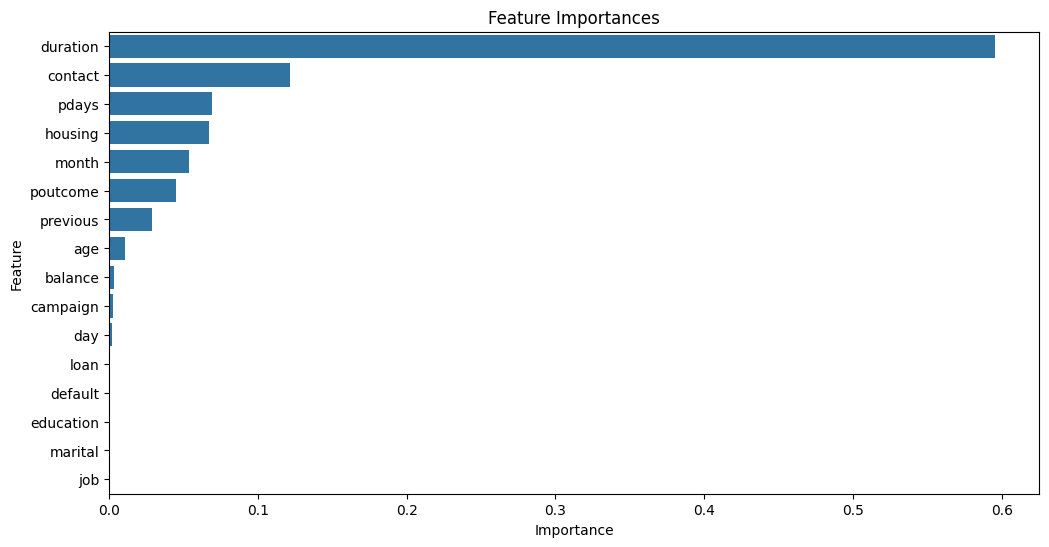

In [28]:
# Plot feature importance graph
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[sorted_indices], y=X.columns[sorted_indices])
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Interpret: Which features influence prediction the most?

Based on the feature importances extracted from the Decision Tree Classifier, we can identify the most influential features:

**Top 5 Important Features:**
1.  **`duration`**: This feature has by far the highest importance score. It represents the last contact duration in seconds. As mentioned in the data understanding, this is a very strong predictor because if the duration is 0, the client could not have subscribed. However, it's crucial to note that this information is only known *after* a call, making it unavailable for real-time prediction before contacting a client. For a truly predictive model used *before* a campaign, this feature should ideally be excluded.
2.  **`contact`**: The type of contact communication used with the client. This indicates that the method of communication significantly impacts the likelihood of a deposit.
3.  **`pdays`**: The number of days that passed by after the client was last contacted from a previous campaign. A value of -1 typically means the client was not previously contacted. This suggests that the recency of prior contact (or lack thereof) is an important factor.
4.  **`housing`**: Whether the client has a housing loan. This financial obligation appears to be a significant indicator for deposit subscription.
5.  **`month`**: The last contact month of the year. This could capture seasonality or specific campaign periods that are more effective.

**Interpretation:**

The most dominant feature influencing the prediction is `duration`. This highlights a potential data leakage issue if the model is intended for prospective campaign targeting, as `duration` is a post-event variable. If `duration` were removed, `contact`, `pdays`, `housing`, and `month` would become the most relevant factors. Businesses could leverage this information to:

*   **Optimize contact strategies**: Tailor communication methods based on what's most effective.
*   **Target clients based on past engagement**: Focus on clients with recent past interactions or specific `pdays` values.
*   **Segment based on financial status**: Use information like `housing` loans to identify more (or less) receptive groups.
*   **Plan campaigns seasonally**: Understand which months are most opportune for marketing efforts.

**Q15. Business Insights**

Based on your model:

Answer:

Which type of customers are more likely to say “yes”?

What strategy should a bank us

### Q15. Business Insights

Based on the Decision Tree model and the feature importance analysis, here are the business insights:

**Which type of customers are more likely to say “yes”?**

Customers who are more likely to subscribe to a term deposit (say "yes") generally exhibit the following characteristics, primarily influenced by the top features:

1.  **Customers with longer contact durations:** As `duration` was the most important feature, customers who engage in longer conversations during the last contact are significantly more likely to subscribe. (However, as noted, `duration` is known post-call, so it's not useful for pre-campaign targeting.)
2.  **Customers engaged through effective contact types:** The `contact` type is a crucial indicator. Customers responding positively to specific communication channels (e.g., cellular) are more prone to subscribe.
3.  **Customers with recent or no prior campaign contact (`pdays`):** Clients who were either recently contacted from a previous campaign (`pdays` is small and positive) or those who have no record of prior contact (`pdays` is -1) are more likely to convert. This suggests either a fresh approach or a follow-up on recent interactions is effective.
4.  **Customers without a housing loan (`housing`):** Individuals who do not have a housing loan tend to be more receptive. This could indicate a greater financial flexibility or less debt burden, making them more open to investing in a term deposit.
5.  **Customers contacted in certain months (`month`):** There might be specific months of the year when customers are more receptive to offers. This could be due to seasonal financial behaviors or bank campaign scheduling.

In summary, clients who are engaged through effective channels, have fewer existing financial commitments like housing loans, and are contacted at opportune times are more inclined to subscribe.

**What strategy should a bank use?**

Given these insights, a bank could adopt the following strategies to improve term deposit subscriptions:

1.  **Optimize Contact Channels:** Analyze the effectiveness of different `contact` types. If certain channels (e.g., cellular) show higher conversion rates, prioritize these for reaching potential subscribers. Invest in training call center agents on effective communication for these channels.

2.  **Strategic Timing of Campaigns (Leveraging `month` and `pdays`):**
    *   **Seasonal Campaigns:** Identify the `month`s that historically yield higher subscription rates and concentrate marketing efforts during these periods.
    *   **Follow-up Strategy:** For clients previously contacted in a campaign, develop a strategy to re-engage them within a specific `pdays` window that has shown higher success rates. For new clients, ensure the initial contact is compelling.

3.  **Targeting Based on Financial Profile (Leveraging `housing`):**
    *   **Segmented Marketing:** Create targeted campaigns for customers *without* housing loans, as they appear to be a more receptive segment. The messaging for this group could focus on wealth growth and savings.
    *   **Alternative Offers:** For customers with housing loans, the bank might need to offer more tailored products or different incentives, as they are less likely to subscribe to term deposits based on this model.

4.  **Focus on Engagement (Pre-call indicators):** Since `duration` is a post-call metric, the bank should focus on pre-call indicators to identify potential high-engagement customers. While the model doesn't directly provide these, historical data on factors that lead to longer call durations could be indirectly used (e.g., specific customer segments, prior interactions, referral sources).

5.  **Data-Driven Messaging:** Tailor marketing messages based on these identified customer profiles. For instance, for customers without housing loans, emphasize long-term financial growth and savings opportunities. For customers in receptive months, create time-sensitive offers.

By implementing these strategies, the bank can refine its marketing campaigns, allocate resources more efficiently, and ultimately increase the success rate of term deposit subscriptions.